# Full-dataset base-model grading comparison

This notebook evaluates eight instruction-tuned base models on every row of `training_data.csv`. Thinking runs are currently disabled so only the faster non-thinking mode is evaluated.

All runs use the same grading prompt, deterministic decoding, parser, dataset labels, and metrics used by the archived QLoRA notebooks. Models are loaded with 4-bit NF4 quantization to fit the available VRAM. Each model is deleted and the CUDA cache is cleared before the next model is loaded.

The requested model names map to these official repositories:

- `Qwen/Qwen3.5-4B`
- `Qwen/Qwen3.5-9B`
- `Qwen/Qwen3.5-27B`
- `Qwen/Qwen3.8-27B`
- `google/gemma-4-12B-it`
- `ibm-granite/granite-4.2-8b`
- `ornith-ai/Ornith-1.5-9B`

> The enabled non-thinking benchmark contains 17,320 model/example combinations (2,165 rows × 8 models). Results are checkpointed after every batch and completed runs are reused when the cell is restarted. Uncomment the thinking entry in Section 2 to restore the second set of runs.


## 1. Install inference and analysis dependencies

Recent Transformers support is required for Qwen3.8, Gemma 4, Granite 4.2, and Ornith 1.5. Restart the kernel after this cell if packages are upgraded.


In [1]:
%pip install -U "transformers>=5.16.1" accelerate bitsandbytes kernels torchvision sentencepiece pandas scikit-learn matplotlib tqdm


Note: you may need to restart the kernel to use updated packages.


## 2. Imports and experiment configuration

The thinking budget is larger because reasoning tokens precede the final JSON array. Greedy decoding keeps comparisons reproducible. Per-model starting batch sizes are tuned for 24 GB of VRAM, and the evaluator automatically retries with a smaller batch after a CUDA out-of-memory error.


In [2]:
import ast
import csv
import gc
import json
import os
import re
import time
from pathlib import Path

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import torch
from IPython.display import display
from sklearn.metrics import accuracy_score, f1_score, precision_score, recall_score
from tqdm.auto import tqdm
from transformers import (
    AutoModelForCausalLM,
    AutoModelForMultimodalLM,
    AutoProcessor,
    AutoTokenizer,
    BitsAndBytesConfig,
)

if not torch.cuda.is_available():
    raise RuntimeError("A CUDA GPU is required for this benchmark.")

# Load the Hugging Face access token without displaying its secret value.
def read_env_value(path, key):
    if not path.exists():
        raise FileNotFoundError(f"Missing environment file: {path.resolve()}")
    for raw_line in path.read_text(encoding="utf-8").splitlines():
        line = raw_line.strip()
        if not line or line.startswith("#") or "=" not in line:
            continue
        name, value = line.split("=", 1)
        name = name.strip().removeprefix("export ").strip()
        if name != key:
            continue
        value = value.strip()
        if len(value) >= 2 and value[0] == value[-1] and value[0] in ("'", '"'):
            value = value[1:-1]
        return value
    return None

ENV_PATH = Path("./.env")
HF_TOKEN = read_env_value(ENV_PATH, "HF_TOKEN")
if not HF_TOKEN:
    raise RuntimeError("HF_TOKEN is missing or empty in .env.")
os.environ["HF_TOKEN"] = HF_TOKEN
print("HF_TOKEN loaded from .env.")

DATASET_PATH = Path("./training_data.csv")
RESULTS_DIR = Path("./base_model_results")
RESULTS_DIR.mkdir(parents=True, exist_ok=True)

# Increment this tag whenever prompts or generation settings change.
RUN_TAG = "full_dataset_nf4_v1"
OVERWRITE_EXISTING = False

# Non-thinking is enabled for the main benchmark. Thinking is retained as
# an opt-in run because its longer generations make the full dataset slow.
THINKING_MODES = [
    False,
    # True,  # Uncomment to add thinking-mode runs.
]
MAX_NEW_TOKENS = {False: 128, True: 1024}

MODEL_SPECS = [
    {"name": "Qwen3.5 4B", "model_id": "Qwen/Qwen3.5-4B", "loader": "multimodal", "batch_size": 16},
    {"name": "Qwen3.5 9B", "model_id": "Qwen/Qwen3.5-9B", "loader": "multimodal", "batch_size": 8},
    {"name": "Qwen3.5 27B", "model_id": "Qwen/Qwen3.5-27B", "loader": "multimodal", "batch_size": 2},
    {"name": "Qwen3.8 27B", "model_id": "Qwen/Qwen3.8-27B", "loader": "multimodal", "batch_size": 2},
    {"name": "Gemma 4 12B", "model_id": "google/gemma-4-12B-it", "loader": "multimodal", "batch_size": 4},
    {"name": "Granite 4.2 8B", "model_id": "ibm-granite/granite-4.2-8b", "loader": "causal_lm", "batch_size": 8},
    {"name": "Ornith 1.5 9B", "model_id": "ornith-ai/Ornith-1.5-9B", "loader": "multimodal", "batch_size": 8},
]

compute_dtype = torch.bfloat16 if torch.cuda.is_bf16_supported() else torch.float16
bnb_config = BitsAndBytesConfig(
    load_in_4bit=True,
    bnb_4bit_quant_type="nf4",
    bnb_4bit_use_double_quant=True,
    bnb_4bit_compute_dtype=compute_dtype,
)

print("PyTorch:", torch.__version__)
print("Transformers GPU:", torch.cuda.get_device_name(0))
print(f"VRAM: {torch.cuda.get_device_properties(0).total_memory / 1024**3:.1f} GB")
print("Compute dtype:", compute_dtype)
print("Models:", len(MODEL_SPECS), "| modes per model:", len(THINKING_MODES))


HF_TOKEN loaded from .env.
PyTorch: 2.14.0+cu130
Transformers GPU: NVIDIA GeForce RTX 4090
VRAM: 22.0 GB
Compute dtype: torch.bfloat16
Models: 7 | modes per model: 1


## 3. Load and validate the full dataset

This is the same parser used in the archived notebooks. No train/validation/test split is made: every valid CSV row is included in this base-model benchmark.


In [3]:
def parse_array(value):
    """Parse JSON/Python lists and the dataset's quoted [a,b] format."""
    if isinstance(value, list):
        return value
    if pd.isna(value):
        return []
    if not isinstance(value, str):
        raise TypeError(f"Expected list-like string, got {type(value)}")

    text = value.strip()
    for _ in range(2):
        try:
            parsed = json.loads(text)
        except json.JSONDecodeError:
            break
        if isinstance(parsed, list):
            return parsed
        if isinstance(parsed, str):
            text = parsed.strip()
            continue
        break

    try:
        parsed = ast.literal_eval(text)
        if isinstance(parsed, list):
            return parsed
        if isinstance(parsed, str):
            text = parsed.strip()
    except (ValueError, SyntaxError):
        pass

    if not (text.startswith("[") and text.endswith("]")):
        raise ValueError(f"Expected a bracketed list, got: {value!r}")
    inner = text[1:-1].strip()
    if not inner:
        return []
    if re.search(r",(?=Answer\s)", inner):
        items = re.split(r",(?=Answer\s)", inner)
    else:
        items = next(csv.reader([inner], skipinitialspace=True))
    return [item.strip() for item in items]


def parse_criteria(value, expected_count):
    """Use the label count to resolve commas embedded in criteria text."""
    items = parse_array(value)
    if len(items) == expected_count:
        return items

    text = value.strip()
    for _ in range(2):
        try:
            decoded = json.loads(text)
        except json.JSONDecodeError:
            break
        if isinstance(decoded, str):
            text = decoded.strip()
        else:
            break

    if text.startswith("[") and text.endswith("]"):
        inner = text[1:-1].strip()
        items = [inner] if expected_count == 1 else re.split(r",(?=Answer\s)", inner)
    items = [item.strip() for item in items]
    if len(items) != expected_count:
        raise ValueError(
            f"Parsed {len(items)} criteria but expected {expected_count}: {value!r}"
        )
    return items


df = pd.read_csv(DATASET_PATH).reset_index(drop=True)
required_columns = [
    "question", "desired_answer", "student_answer",
    "criteria[]", "criteria_score[]", "criteria_max_score[]",
    "student_score",
]
missing = [column for column in required_columns if column not in df.columns]
if missing:
    raise ValueError(f"Missing required columns: {missing}")

df["criteria_score"] = df["criteria_score[]"].apply(
    lambda value: [int(x) for x in parse_array(value)]
)
df["criteria"] = df.apply(
    lambda row: parse_criteria(row["criteria[]"], len(row["criteria_score"])),
    axis=1,
)
df["criteria_max_score"] = df["criteria_max_score[]"].apply(
    lambda value: [int(x) for x in parse_array(value)]
)
df["student_score"] = pd.to_numeric(df["student_score"], errors="raise")

validation_errors = []
for index, row in df.iterrows():
    lengths = (len(row["criteria"]), len(row["criteria_score"]), len(row["criteria_max_score"]))
    if len(set(lengths)) != 1 or lengths[0] == 0:
        validation_errors.append(f"row {index}: misaligned lengths {lengths}")
    if any(score not in (0, 1) for score in row["criteria_score"]):
        validation_errors.append(f"row {index}: labels must be binary")
    if any(maximum < 0 for maximum in row["criteria_max_score"]):
        validation_errors.append(f"row {index}: maximum scores must be non-negative")
    reconstructed_score = sum(
        score * maximum
        for score, maximum in zip(row["criteria_score"], row["criteria_max_score"])
    )
    if abs(reconstructed_score - float(row["student_score"])) > 1e-9:
        validation_errors.append(
            f"row {index}: student_score does not match weighted criterion labels"
        )

if validation_errors:
    raise ValueError("Dataset validation failed:\n" + "\n".join(validation_errors[:20]))

print("Full dataset rows:", len(df))
print("Total criterion labels:", sum(df["criteria_score"].map(len)))
print("Maximum criteria in one row:", max(df["criteria_score"].map(len)))
display(df[["question", "student_answer", "criteria", "criteria_score", "student_score"]].head())


Full dataset rows: 2165
Total criterion labels: 3712
Maximum criteria in one row: 5


,question,student_answer,criteria,criteria_score,student_score
0,What is the role of a prototype program in pro...,High risk problems are address in the prototyp...,[Answer mentions simulating behaviour of porti...,[0],0
1,What is the role of a prototype program in pro...,To simulate portions of the desired final prod...,[Answer mentions simulating behaviour of porti...,[1],1
2,What is the role of a prototype program in pro...,A prototype program simulates the behaviors of...,[Answer mentions simulating behaviour of porti...,[1],1
3,What is the role of a prototype program in pro...,Defined in the Specification phase a prototype...,[Answer mentions simulating behaviour of porti...,[1],1
4,What is the role of a prototype program in pro...,It is used to let the users have a first idea ...,[Answer mentions simulating behaviour of porti...,[0],0


## 4. Shared grading prompt and strict output parser

The final answer must be one ordered binary JSON array. In thinking mode, reasoning may appear before the answer; the parser selects the last binary array with the required length.


In [4]:
SYSTEM_PROMPT = (
    "You are a strict grading assistant.\n\n"
    "Your task is to evaluate whether a student's answer fulfills each grading criterion.\n\n"
    "For each criterion:\n"
    "- Output 1 if the criterion is fulfilled.\n"
    "- Output 0 if the criterion is not fulfilled.\n\n"
    "Evaluate each criterion independently.\n\n"
    "Return ONLY a valid JSON array containing 0 or 1.\n"
    "The output array must contain exactly one value for each criterion, "
    "in the same order as the criteria provided.\n\n"
    "Do not include explanations in the final answer.\n"
    "Do not include markdown in the final answer.\n"
    "Do not include any text after the final JSON array."
)


def build_messages(row):
    criteria_text = "\n".join(
        f"{index + 1}. {criterion}"
        for index, criterion in enumerate(row["criteria"])
    )
    user_prompt = (
        f"Question:\n{row['question']}\n\n"
        f"Desired answer:\n{row['desired_answer']}\n\n"
        f"Student answer:\n{row['student_answer']}\n\n"
        f"Criteria:\n{criteria_text}"
    )
    return [
        {"role": "system", "content": SYSTEM_PROMPT},
        {"role": "user", "content": user_prompt},
    ]


def parse_prediction(raw_output, expected_count):
    """Return a valid binary array, tolerating a preceding thinking trace."""
    text = raw_output.strip()
    final_segment = text.rsplit("</think>", 1)[-1].strip()

    candidates = []
    for candidate_text in (final_segment, text):
        try:
            parsed = json.loads(candidate_text)
            candidates.append(parsed)
        except json.JSONDecodeError:
            pass

    for match in re.findall(r"\[\s*[01](?:\s*,\s*[01])*\s*\]", text):
        candidates.append(json.loads(match))

    for candidate in reversed(candidates):
        if not isinstance(candidate, list):
            continue
        try:
            scores = [int(value) for value in candidate]
        except (TypeError, ValueError):
            continue
        if len(scores) == expected_count and all(value in (0, 1) for value in scores):
            return {"valid": True, "scores": scores, "error": None}

    return {
        "valid": False,
        "scores": None,
        "error": f"No binary JSON array of length {expected_count} was found.",
    }

print(SYSTEM_PROMPT)


You are a strict grading assistant.

Your task is to evaluate whether a student's answer fulfills each grading criterion.

For each criterion:
- Output 1 if the criterion is fulfilled.
- Output 0 if the criterion is not fulfilled.

Evaluate each criterion independently.

Return ONLY a valid JSON array containing 0 or 1.
The output array must contain exactly one value for each criterion, in the same order as the criteria provided.

Do not include explanations in the final answer.
Do not include markdown in the final answer.
Do not include any text after the final JSON array.


## 5. Model loading, thinking control, and VRAM cleanup

Multimodal model classes are used for Qwen, Gemma, and Ornith; Granite uses its causal-language-model class. Only text is supplied. The prompt is checked to ensure that each model's chat template actually changes when thinking is toggled.


In [5]:
def clear_cuda_cache():
    gc.collect()
    torch.cuda.empty_cache()
    if hasattr(torch.cuda, "ipc_collect"):
        torch.cuda.ipc_collect()


def print_vram(prefix):
    allocated = torch.cuda.memory_allocated() / 1024**3
    reserved = torch.cuda.memory_reserved() / 1024**3
    print(f"{prefix}: allocated={allocated:.2f} GiB, reserved={reserved:.2f} GiB")


def load_processor(model_id):
    try:
        processor = AutoProcessor.from_pretrained(
            model_id, token=HF_TOKEN, trust_remote_code=True
        )
    except (ValueError, OSError):
        processor = AutoTokenizer.from_pretrained(
            model_id, token=HF_TOKEN, trust_remote_code=True
        )
    tokenizer = getattr(processor, "tokenizer", processor)
    if tokenizer.pad_token_id is None:
        tokenizer.pad_token = tokenizer.eos_token
    tokenizer.padding_side = "left"
    return processor, tokenizer


def load_model(spec):
    print(f"Loading {spec['name']} from {spec['model_id']}")
    processor, tokenizer = load_processor(spec["model_id"])
    model_class = (
        AutoModelForMultimodalLM
        if spec["loader"] == "multimodal"
        else AutoModelForCausalLM
    )
    model = model_class.from_pretrained(
        spec["model_id"],
        quantization_config=bnb_config,
        dtype=compute_dtype,
        device_map="auto",
        low_cpu_mem_usage=True,
        trust_remote_code=True,
        token=HF_TOKEN,
    )
    model.eval()
    if hasattr(model.config, "use_cache"):
        model.config.use_cache = True
    print_vram(f"After loading {spec['name']}")
    return model, processor, tokenizer


def render_prompt(processor, messages, thinking):
    return processor.apply_chat_template(
        messages,
        tokenize=False,
        add_generation_prompt=True,
        enable_thinking=thinking,
    )


def verify_thinking_toggle(processor):
    sample_messages = build_messages(df.iloc[0])
    direct_prompt = render_prompt(processor, sample_messages, thinking=False)
    thinking_prompt = render_prompt(processor, sample_messages, thinking=True)
    if direct_prompt == thinking_prompt:
        raise RuntimeError(
            "This model's chat template ignored enable_thinking; the two runs "
            "would not be a valid thinking/non-thinking comparison."
        )
    print("Thinking toggle verified in the chat template.")


## 6. Resumable inference and metric calculation

Each model/mode pair writes one JSONL file under `base_model_results`. If execution is interrupted, rerunning the benchmark skips completed dataset indices. Invalid outputs count as failures for response-level and final-score accuracies, matching the archived evaluation. Criterion-level metrics and MAE/RMSE use structurally valid predictions, also matching the archived code.


In [6]:
METRIC_COLUMNS = [
    "invalid_output_rate",
    "exact_match_accuracy",
    "per_criterion_accuracy",
    "precision",
    "recall",
    "f1",
    "final_score_exact_accuracy",
    "final_score_within_one_accuracy",
    "final_score_mae",
    "final_score_rmse",
]


def mode_name(thinking):
    return "thinking" if thinking else "non-thinking"


def run_slug(spec, thinking):
    name = re.sub(r"[^a-z0-9]+", "_", spec["name"].lower()).strip("_")
    return f"{RUN_TAG}__{name}__{mode_name(thinking)}"


def prediction_path(spec, thinking):
    return RESULTS_DIR / f"{run_slug(spec, thinking)}.jsonl"


def load_prediction_records(path):
    if not path.exists():
        return []
    records = []
    with path.open("r", encoding="utf-8") as handle:
        for line_number, line in enumerate(handle, start=1):
            if not line.strip():
                continue
            try:
                records.append(json.loads(line))
            except json.JSONDecodeError:
                print(f"Ignoring incomplete JSONL line {line_number} in {path.name}")
    # If an interrupted retry produced a duplicate, retain the latest record.
    by_index = {int(record["dataset_index"]): record for record in records}
    return [by_index[index] for index in sorted(by_index)]


def append_prediction_records(path, records):
    with path.open("a", encoding="utf-8") as handle:
        for record in records:
            handle.write(json.dumps(record, ensure_ascii=False) + "\n")


def input_device_for(model):
    try:
        return model.get_input_embeddings().weight.device
    except (AttributeError, NotImplementedError):
        return next(model.parameters()).device


def generate_batch(model, processor, tokenizer, rows, thinking):
    prompts = [
        render_prompt(processor, build_messages(row), thinking=thinking)
        for row in rows
    ]
    inputs = tokenizer(
        prompts,
        return_tensors="pt",
        padding=True,
        add_special_tokens=False,
    )
    input_width = inputs["input_ids"].shape[1]
    device = input_device_for(model)
    inputs = {key: value.to(device) for key, value in inputs.items()}

    started = time.perf_counter()
    with torch.inference_mode():
        generated = model.generate(
            **inputs,
            max_new_tokens=MAX_NEW_TOKENS[thinking],
            do_sample=False,
            use_cache=True,
            pad_token_id=tokenizer.pad_token_id,
        )
    elapsed = time.perf_counter() - started
    continuation_ids = generated[:, input_width:].detach().cpu()
    outputs = tokenizer.batch_decode(continuation_ids, skip_special_tokens=True)

    del inputs, generated, continuation_ids
    return [output.strip() for output in outputs], elapsed


def calculate_metrics(records, spec, thinking):
    if len(records) != len(df):
        raise ValueError(f"Expected {len(df)} records but found {len(records)}.")

    criterion_true = []
    criterion_pred = []
    exact_correct = 0
    invalid_count = 0
    final_score_errors = []
    final_score_exact = 0
    final_score_within_one = 0

    for record in records:
        true_scores = record["ground_truth"]
        pred_scores = record["prediction"] if record["valid"] else None
        exact_correct += int(record["valid"] and pred_scores == true_scores)
        invalid_count += int(not record["valid"])

        if record["valid"]:
            criterion_true.extend(true_scores)
            criterion_pred.extend(pred_scores)
            error = abs(record["predicted_final_score"] - record["true_final_score"])
            final_score_errors.append(error)
            final_score_exact += int(error == 0)
            final_score_within_one += int(error <= 1)

    total = len(records)
    elapsed_seconds = sum(float(record.get("generation_seconds", 0.0)) for record in records)
    return {
        "model": spec["name"],
        "model_id": spec["model_id"],
        "mode": mode_name(thinking),
        "examples": total,
        "invalid_output_rate": invalid_count / total if total else 0.0,
        "exact_match_accuracy": exact_correct / total if total else 0.0,
        "per_criterion_accuracy": accuracy_score(criterion_true, criterion_pred) if criterion_true else 0.0,
        "precision": precision_score(criterion_true, criterion_pred, zero_division=0) if criterion_true else 0.0,
        "recall": recall_score(criterion_true, criterion_pred, zero_division=0) if criterion_true else 0.0,
        "f1": f1_score(criterion_true, criterion_pred, zero_division=0) if criterion_true else 0.0,
        "final_score_exact_accuracy": final_score_exact / total if total else 0.0,
        "final_score_within_one_accuracy": final_score_within_one / total if total else 0.0,
        "final_score_mae": float(np.mean(final_score_errors)) if final_score_errors else float("nan"),
        "final_score_rmse": float(np.sqrt(np.mean(np.square(final_score_errors)))) if final_score_errors else float("nan"),
        "generation_minutes": elapsed_seconds / 60,
        "mean_generation_seconds": elapsed_seconds / total if total else float("nan"),
    }


def evaluate_model_mode(model, processor, tokenizer, spec, thinking):
    path = prediction_path(spec, thinking)
    if OVERWRITE_EXISTING and path.exists():
        path.unlink()

    existing = load_prediction_records(path)
    completed = {int(record["dataset_index"]) for record in existing}
    pending = [index for index in range(len(df)) if index not in completed]
    active_batch_size = spec["batch_size"]

    print(
        f"{spec['name']} | {mode_name(thinking)}: "
        f"{len(completed)} complete, {len(pending)} remaining"
    )

    position = 0
    with tqdm(total=len(pending), desc=f"{spec['name']} | {mode_name(thinking)}") as progress:
        while position < len(pending):
            batch_indices = pending[position:position + active_batch_size]
            rows = [df.iloc[index] for index in batch_indices]
            try:
                raw_outputs, elapsed = generate_batch(
                    model, processor, tokenizer, rows, thinking
                )
            except torch.OutOfMemoryError:
                clear_cuda_cache()
                if active_batch_size == 1:
                    raise
                active_batch_size = max(1, active_batch_size // 2)
                print(f"CUDA OOM: retrying with batch size {active_batch_size}")
                continue

            batch_records = []
            seconds_per_example = elapsed / len(batch_indices)
            for dataset_index, row, raw_output in zip(batch_indices, rows, raw_outputs):
                parsed = parse_prediction(raw_output, len(row["criteria_score"]))
                pred_scores = parsed["scores"]
                predicted_final_score = (
                    sum(score * maximum for score, maximum in zip(pred_scores, row["criteria_max_score"]))
                    if parsed["valid"] else None
                )
                batch_records.append({
                    "dataset_index": int(dataset_index),
                    "dataset_id": str(row["id"]) if "id" in row else str(dataset_index),
                    "model": spec["name"],
                    "model_id": spec["model_id"],
                    "mode": mode_name(thinking),
                    "valid": parsed["valid"],
                    "error": parsed["error"],
                    "ground_truth": [int(value) for value in row["criteria_score"]],
                    "prediction": pred_scores,
                    "criteria_max_score": [int(value) for value in row["criteria_max_score"]],
                    "true_final_score": float(row["student_score"]),
                    "predicted_final_score": predicted_final_score,
                    "raw_output": raw_output,
                    "generation_seconds": seconds_per_example,
                })

            append_prediction_records(path, batch_records)
            position += len(batch_indices)
            progress.update(len(batch_indices))

    records = load_prediction_records(path)
    return calculate_metrics(records, spec, thinking), records


## 7. Run all models sequentially

Run this cell to start or resume the benchmark. A model is not loaded when both of its result files are already complete. In all cases, model references are deleted and the CUDA allocator cache is cleared before the next model is loaded.


In [7]:
summary_rows = []
failure_rows = []
summary_path = RESULTS_DIR / f"{RUN_TAG}__summary_metrics.csv"
failure_path = RESULTS_DIR / f"{RUN_TAG}__failures.csv"

for spec in MODEL_SPECS:
    completed_modes = {}
    modes_to_run = []

    for thinking in THINKING_MODES:
        records = load_prediction_records(prediction_path(spec, thinking))
        if not OVERWRITE_EXISTING and len(records) == len(df):
            completed_modes[thinking] = records
            summary_rows.append(calculate_metrics(records, spec, thinking))
            print(f"Reused completed run: {spec['name']} | {mode_name(thinking)}")
        else:
            modes_to_run.append(thinking)

    if modes_to_run:
        model = None
        processor = None
        tokenizer = None
        try:
            clear_cuda_cache()
            model, processor, tokenizer = load_model(spec)
            verify_thinking_toggle(processor)

            for thinking in modes_to_run:
                try:
                    metrics, _ = evaluate_model_mode(
                        model, processor, tokenizer, spec, thinking
                    )
                    summary_rows.append(metrics)
                    current_summary = (
                        pd.DataFrame(summary_rows)
                        .drop_duplicates(["model", "mode"], keep="last")
                    )
                    current_summary.to_csv(summary_path, index=False)
                    display(pd.DataFrame([metrics]).set_index(["model", "mode"]))
                except Exception as error:
                    failure_rows.append({
                        "model": spec["name"],
                        "model_id": spec["model_id"],
                        "mode": mode_name(thinking),
                        "error_type": type(error).__name__,
                        "error": str(error),
                    })
                    pd.DataFrame(failure_rows).to_csv(failure_path, index=False)
                    print(f"FAILED: {spec['name']} | {mode_name(thinking)}: {error}")
        finally:
            # Remove every live reference before loading another model.
            if model is not None:
                del model
            if processor is not None:
                del processor
            if tokenizer is not None:
                del tokenizer
            clear_cuda_cache()
            print_vram(f"After unloading {spec['name']}")

summary_df = (
    pd.DataFrame(summary_rows)
    .drop_duplicates(["model", "mode"], keep="last")
)
summary_df.to_csv(summary_path, index=False)

if failure_rows:
    display(pd.DataFrame(failure_rows))

display(summary_df.set_index(["model", "mode"]))


Reused completed run: Qwen3.5 4B | non-thinking
Reused completed run: Qwen3.5 9B | non-thinking
Reused completed run: Qwen3.5 27B | non-thinking
Reused completed run: Qwen3.8 27B | non-thinking
Reused completed run: Gemma 4 12B | non-thinking
Loading Granite 4.2 8B from ibm-granite/granite-4.2-8b


Loading weights:   0%|          | 0/363 [00:00<?, ?it/s]

After loading Granite 4.2 8B: allocated=5.38 GiB, reserved=5.61 GiB
Thinking toggle verified in the chat template.
Granite 4.2 8B | non-thinking: 0 complete, 2165 remaining


Granite 4.2 8B | non-thinking:   0%|          | 0/2165 [00:00<?, ?it/s]

,,model_id,examples,invalid_output_rate,exact_match_accuracy,per_criterion_accuracy,precision,recall,f1,final_score_exact_accuracy,final_score_within_one_accuracy,final_score_mae,final_score_rmse,generation_minutes,mean_generation_seconds
model,mode,,,,,,,,,,,,,,
Granite 4.2 8B,non-thinking,ibm-granite/granite-4.2-8b,2165,0.0,0.612009,0.725216,0.713924,0.896051,0.794686,0.626328,0.940416,0.440647,0.77131,9.416635,0.260969


...

After loading Ornith 1.5 9B: allocated=7.36 GiB, reserved=7.41 GiB
Thinking toggle verified in the chat template.
Ornith 1.5 9B | non-thinking: 0 complete, 2165 remaining


Ornith 1.5 9B | non-thinking:   0%|          | 0/2165 [00:00<?, ?it/s]

,,model_id,examples,invalid_output_rate,exact_match_accuracy,per_criterion_accuracy,precision,recall,f1,final_score_exact_accuracy,final_score_within_one_accuracy,final_score_mae,final_score_rmse,generation_minutes,mean_generation_seconds
model,mode,,,,,,,,,,,,,,
Ornith 1.5 9B,non-thinking,ornith-ai/Ornith-1.5-9B,2165,0.004619,0.582448,0.716956,0.699235,0.917846,0.793764,0.6097,0.961201,0.425522,0.717368,2.530545,0.070131


After unloading Ornith 1.5 9B: allocated=0.01 GiB, reserved=0.10 GiB


,,model_id,examples,invalid_output_rate,exact_match_accuracy,per_criterion_accuracy,precision,recall,f1,final_score_exact_accuracy,final_score_within_one_accuracy,final_score_mae,final_score_rmse,generation_minutes,mean_generation_seconds
model,mode,,,,,,,,,,,,,,
Qwen3.5 4B,non-thinking,Qwen/Qwen3.5-4B,2165,0.000000,0.643418,0.750269,0.895291,0.655924,0.757139,0.647575,0.938106,0.418938,0.750981,3.065096,0.084945
Qwen3.5 9B,non-thinking,Qwen/Qwen3.5-9B,2165,0.000000,0.676674,0.783675,0.820220,0.813890,0.817043,0.683603,0.963972,0.356120,0.669701,2.918192,0.080874
Qwen3.5 27B,non-thinking,Qwen/Qwen3.5-27B,2165,0.000000,0.730716,0.823276,0.883871,0.808443,0.844476,0.742263,0.979677,0.279908,0.575079,12.128355,0.336121
Qwen3.8 27B,non-thinking,Qwen/Qwen3.8-27B,2165,0.000000,0.706697,0.807651,0.907945,0.752156,0.822741,0.713164,0.971824,0.316859,0.619170,12.017762,0.333056
Gemma 4 12B,non-thinking,google/gemma-4-12B-it,2165,0.000000,0.721940,0.813847,0.878758,0.796187,0.835437,0.727021,0.968129,0.309007,0.628426,4.068681,0.112758
Granite 4.2 8B,non-thinking,ibm-granite/granite-4.2-8b,2165,0.000000,0.612009,0.725216,0.713924,0.896051,0.794686,0.626328,0.940416,0.440647,0.771310,9.416635,0.260969
Ornith 1.5 9B,non-thinking,ornith-ai/Ornith-1.5-9B,2165,0.004619,0.582448,0.716956,0.699235,0.917846,0.793764,0.609700,0.961201,0.425522,0.717368,2.530545,0.070131


## 8. Side-by-side metric tables

The first table is a conventional long-form summary. The second places enabled modes beside one another for every metric; thinking columns appear automatically if thinking runs are re-enabled.


In [10]:
summary_path = RESULTS_DIR / f"{RUN_TAG}__summary_metrics.csv"
if not summary_path.exists():
    raise FileNotFoundError("Run Section 7 before building comparison tables.")

summary_df = pd.read_csv(summary_path)
model_order = [spec["name"] for spec in MODEL_SPECS]
summary_df["model"] = pd.Categorical(summary_df["model"], model_order, ordered=True)
summary_df = summary_df.sort_values(["model", "mode"]).reset_index(drop=True)

display(
    summary_df[["model", "mode", *METRIC_COLUMNS]]
    .set_index(["model", "mode"])
    .style.format("{:.4f}")
)

side_by_side_df = (
    summary_df.set_index(["model", "mode"])[METRIC_COLUMNS]
    .unstack("mode")
)
display(side_by_side_df.style.format("{:.4f}"))

side_by_side_df.to_csv(RESULTS_DIR / f"{RUN_TAG}__side_by_side_metrics.csv")


,,invalid_output_rate,exact_match_accuracy,per_criterion_accuracy,precision,recall,f1,final_score_exact_accuracy,final_score_within_one_accuracy,final_score_mae,final_score_rmse
model,mode,,,,,,,,,,
Qwen3.5 4B,non-thinking,0.0000,0.6434,0.7503,0.8953,0.6559,0.7571,0.6476,0.9381,0.4189,0.7510
Qwen3.5 9B,non-thinking,0.0000,0.6767,0.7837,0.8202,0.8139,0.8170,0.6836,0.9640,0.3561,0.6697
Qwen3.5 27B,non-thinking,0.0000,0.7307,0.8233,0.8839,0.8084,0.8445,0.7423,0.9797,0.2799,0.5751
Qwen3.8 27B,non-thinking,0.0000,0.7067,0.8077,0.9079,0.7522,0.8227,0.7132,0.9718,0.3169,0.6192
Gemma 4 12B,non-thinking,0.0000,0.7219,0.8138,0.8788,0.7962,0.8354,0.7270,0.9681,0.3090,0.6284
Granite 4.2 8B,non-thinking,0.0000,0.6120,0.7252,0.7139,0.8961,0.7947,0.6263,0.9404,0.4406,0.7713
Ornith 1.5 9B,non-thinking,0.0046,0.5824,0.7170,0.6992,0.9178,0.7938,0.6097,0.9612,0.4255,0.7174


,invalid_output_rate,exact_match_accuracy,per_criterion_accuracy,precision,recall,f1,final_score_exact_accuracy,final_score_within_one_accuracy,final_score_mae,final_score_rmse
mode,non-thinking,non-thinking,non-thinking,non-thinking,non-thinking,non-thinking,non-thinking,non-thinking,non-thinking,non-thinking
model,,,,,,,,,,
Qwen3.5 4B,0.0000,0.6434,0.7503,0.8953,0.6559,0.7571,0.6476,0.9381,0.4189,0.7510
Qwen3.5 9B,0.0000,0.6767,0.7837,0.8202,0.8139,0.8170,0.6836,0.9640,0.3561,0.6697
Qwen3.5 27B,0.0000,0.7307,0.8233,0.8839,0.8084,0.8445,0.7423,0.9797,0.2799,0.5751
Qwen3.8 27B,0.0000,0.7067,0.8077,0.9079,0.7522,0.8227,0.7132,0.9718,0.3169,0.6192
Gemma 4 12B,0.0000,0.7219,0.8138,0.8788,0.7962,0.8354,0.7270,0.9681,0.3090,0.6284
Granite 4.2 8B,0.0000,0.6120,0.7252,0.7139,0.8961,0.7947,0.6263,0.9404,0.4406,0.7713
Ornith 1.5 9B,0.0046,0.5824,0.7170,0.6992,0.9178,0.7938,0.6097,0.9612,0.4255,0.7174


## 9. Performance graphs

Accuracy, precision, recall, and F1 are higher-is-better. Invalid-output rate, MAE, and RMSE are lower-is-better. A final chart shows the change caused by enabling thinking for selected metrics.


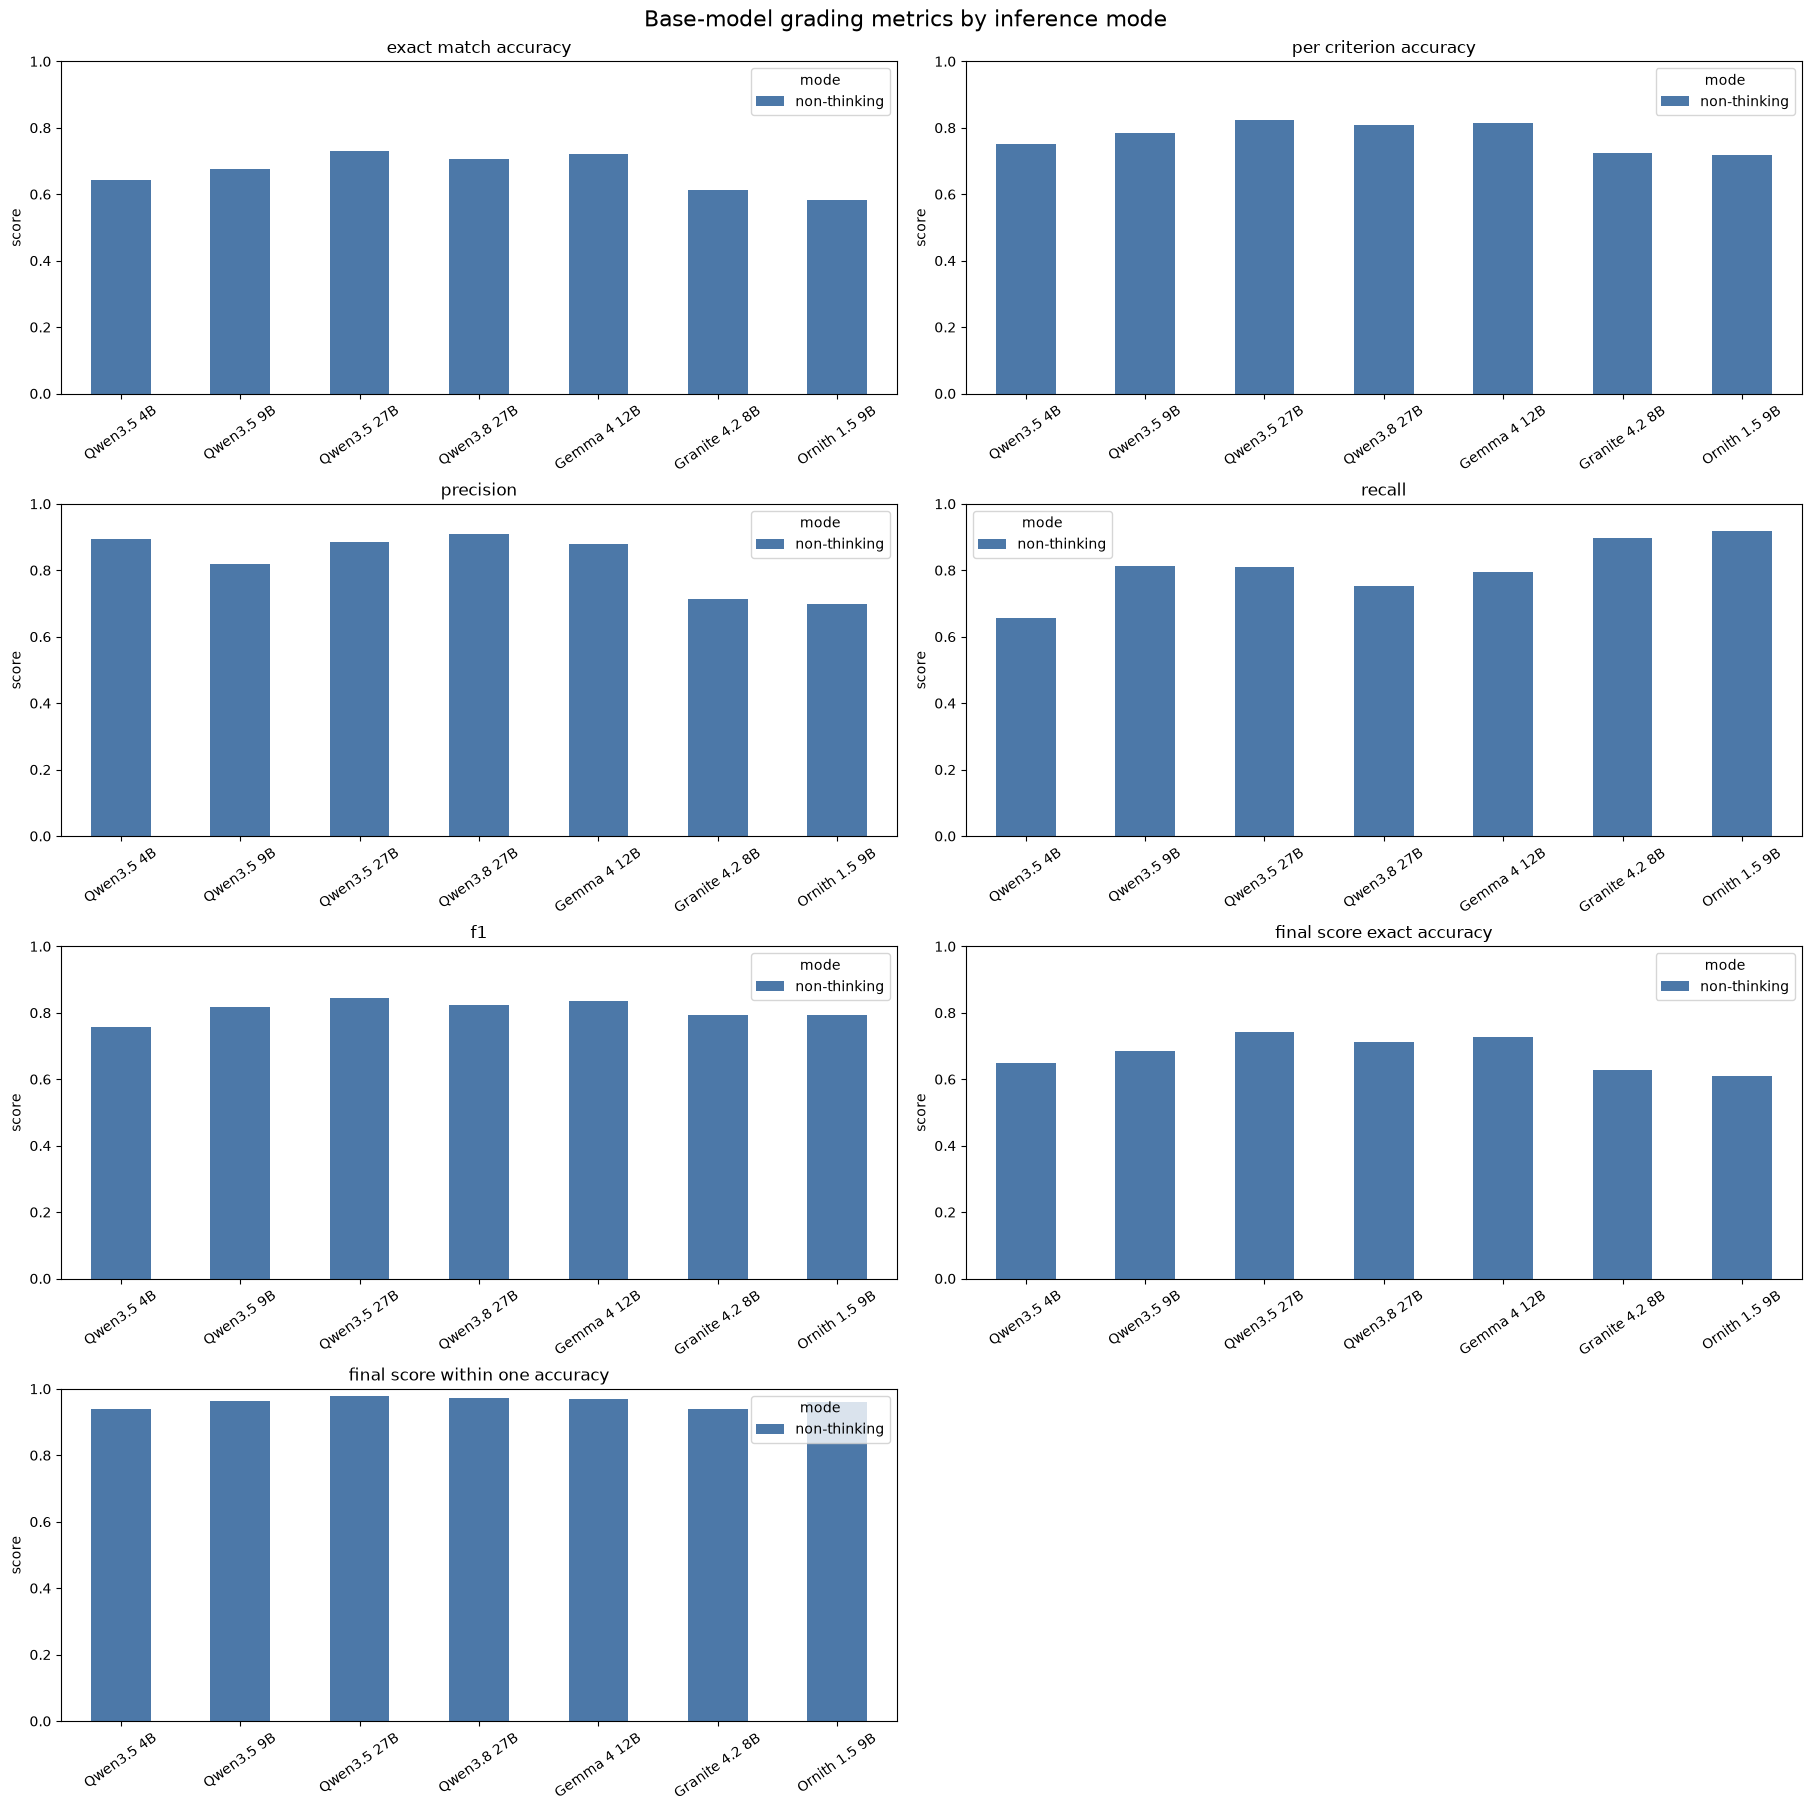

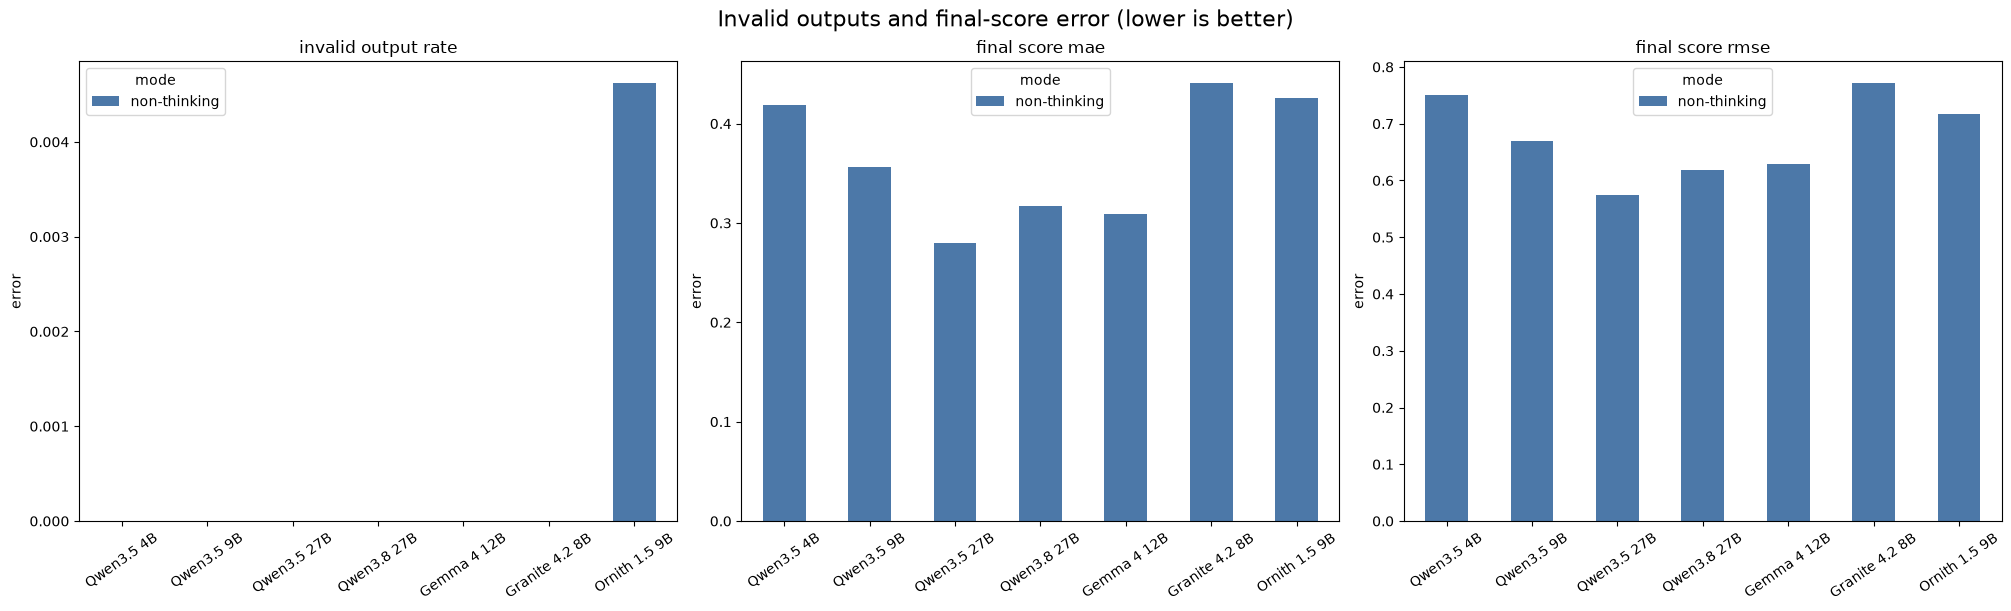

Thinking-delta graph skipped because thinking runs are disabled.


In [11]:
accuracy_metrics = [
    "exact_match_accuracy",
    "per_criterion_accuracy",
    "precision",
    "recall",
    "f1",
    "final_score_exact_accuracy",
    "final_score_within_one_accuracy",
]

fig, axes = plt.subplots(4, 2, figsize=(18, 18), constrained_layout=True)
for axis, metric in zip(axes.flat, accuracy_metrics):
    chart = summary_df.pivot(index="model", columns="mode", values=metric).reindex(model_order)
    chart.plot(kind="bar", ax=axis, color=["#4C78A8", "#F58518"])
    axis.set_title(metric.replace("_", " "))
    axis.set_xlabel("")
    axis.set_ylabel("score")
    axis.set_ylim(0, 1)
    axis.tick_params(axis="x", rotation=35)
    axis.legend(title="mode")
axes.flat[-1].axis("off")
fig.suptitle("Base-model grading metrics by inference mode", fontsize=16)
fig.savefig(RESULTS_DIR / f"{RUN_TAG}__accuracy_metrics.png", dpi=160, bbox_inches="tight")
plt.show()

error_metrics = ["invalid_output_rate", "final_score_mae", "final_score_rmse"]
fig, axes = plt.subplots(1, 3, figsize=(20, 6), constrained_layout=True)
for axis, metric in zip(axes, error_metrics):
    chart = summary_df.pivot(index="model", columns="mode", values=metric).reindex(model_order)
    chart.plot(kind="bar", ax=axis, color=["#4C78A8", "#F58518"])
    axis.set_title(metric.replace("_", " "))
    axis.set_xlabel("")
    axis.set_ylabel("error")
    axis.tick_params(axis="x", rotation=35)
    axis.legend(title="mode")
fig.suptitle("Invalid outputs and final-score error (lower is better)", fontsize=16)
fig.savefig(RESULTS_DIR / f"{RUN_TAG}__error_metrics.png", dpi=160, bbox_inches="tight")
plt.show()

available_modes = set(summary_df["mode"])
if {"non-thinking", "thinking"}.issubset(available_modes):
    delta_metrics = [
        "exact_match_accuracy", "per_criterion_accuracy", "f1",
        "final_score_exact_accuracy",
    ]
    delta_columns = []
    for metric in delta_metrics:
        pivot = summary_df.pivot(index="model", columns="mode", values=metric).reindex(model_order)
        delta_columns.append((pivot["thinking"] - pivot["non-thinking"]).rename(metric))
    thinking_delta_df = pd.concat(delta_columns, axis=1)
    axis = thinking_delta_df.plot(kind="bar", figsize=(16, 7))
    axis.axhline(0, color="black", linewidth=1)
    axis.set_title("Thinking-mode change relative to non-thinking")
    axis.set_ylabel("thinking minus non-thinking")
    axis.set_xlabel("")
    axis.tick_params(axis="x", rotation=35)
    plt.tight_layout()
    plt.savefig(RESULTS_DIR / f"{RUN_TAG}__thinking_delta.png", dpi=160, bbox_inches="tight")
    plt.show()
    display(thinking_delta_df.style.format("{:+.4f}"))
else:
    print("Thinking-delta graph skipped because thinking runs are disabled.")
